Rumusan Masalah:
- Bagaimana karakteristik customer churn berdasarkan wilayah geografis nasabah?
- Bagaimana performa algoritma LightGBM dalam memprediksi customer churn pada dataset nasabah bank?
- Seberapa baik model LightGBM dalam mengklasifikasikan nasabah yang berpotensi churn - berdasarkan metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, dan ROC-AUC?
- Variabel manakah yang memiliki kontribusi terbesar terhadap hasil prediksi churn berdasarkan analisis feature importance pada LightGBM?

Tujuan Penelitian:

- Menganalisis karakteristik nasabah yang melakukan churn dan yang tetap menggunakan layanan bank.
- Mengidentifikasi faktor-faktor yang memengaruhi customer churn.
- Membangun model prediksi customer churn menggunakan algoritma LightGBM.
- Mengevaluasi kinerja model LightGBM menggunakan berbagai metrik evaluasi klasifikasi.
- Menentukan fitur-fitur yang paling berpengaruh terhadap customer churn berdasarkan feature importance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
class DataLoader:
    
    def __init__(self, file_path):
        self.file_path = Path(file_path)
        
    def load_data(self):
        return pd.read_csv(self.file_path)

In [3]:
loader = DataLoader(r"C:\kuliah\tubes STD & Algo\Churn_Modelling.csv")

df = loader.load_data()

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
class DataOverview:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def shape(self):
        print(f"Rows    : {self.df.shape[0]}")
        print(f"Columns : {self.df.shape[1]}")
        
    def info(self):
        return self.df.info()
    
    def missing_values(self):
        return pd.DataFrame({
            "Missing": self.df.isnull().sum(),
            "Percentage": (
                self.df.isnull().sum() /
                len(self.df)
            ) * 100
        }).sort_values(
            by="Missing",
            ascending=False
        )
    
    def descriptive_statistics(self):
        return self.df.describe().T

In [5]:
overview = DataOverview(df)

print("=== Dataset Overview ===")
overview.shape()
print("\n=== Info Data ===")
overview.info()
print("\n=== Missing Values ===")
overview.missing_values()
print("\n=== Descriptive Statistics ===")
overview.descriptive_statistics()

=== Dataset Overview ===
Rows    : 10000
Columns : 14

=== Info Data ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB

=== Missing Values ===

=== Descrip

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [6]:
drop_columns = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

df_eda = df.drop(columns=drop_columns)

df_eda.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
class UnivariateAnalysis:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def numerical_columns(self):
        return self.df.select_dtypes(include=np.number).columns.tolist()
    
    def categorical_columns(self):
        return self.df.select_dtypes(exclude=np.number ).columns.tolist()
    
    def plot_numeric_distribution(self, column):
        
        fig, axes = plt.subplots(1, 2, figsize=(12,4))
        
        sns.histplot(data=self.df, x=column, kde=True, ax=axes[0])
        
        axes[0].set_title(f"Distribution of {column}"
        )
        
        sns.boxplot(data=self.df, x=column, ax=axes[1])
        
        axes[1].set_title(f"Boxplot of {column}")
        
        plt.tight_layout()
        plt.show()
    
    def plot_categorical_distribution(self, column):
        
        plt.figure(figsize=(8,4))
        
        sns.countplot(data=self.df, x=column)
        
        plt.title( f"Distribution of {column}" )

        plt.tick_params
        
        plt.show()

In [8]:
uni = UnivariateAnalysis(df_eda)

In [9]:
uni.numerical_columns()

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

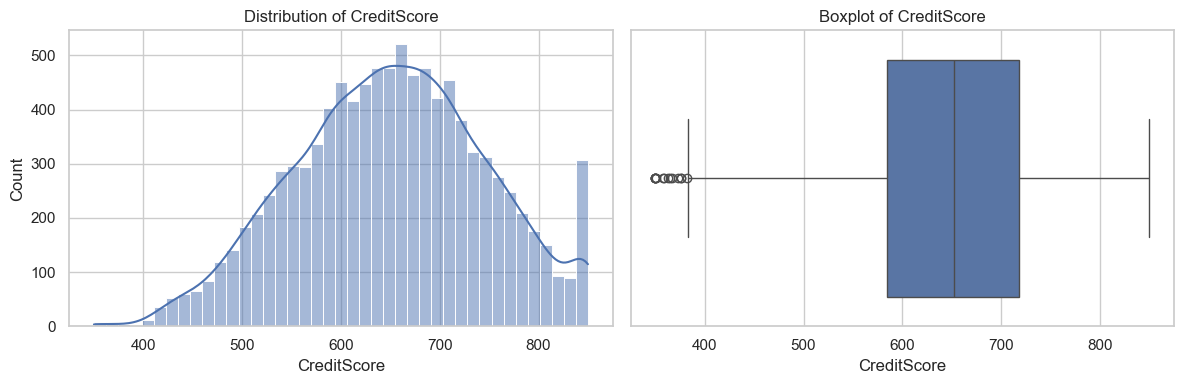

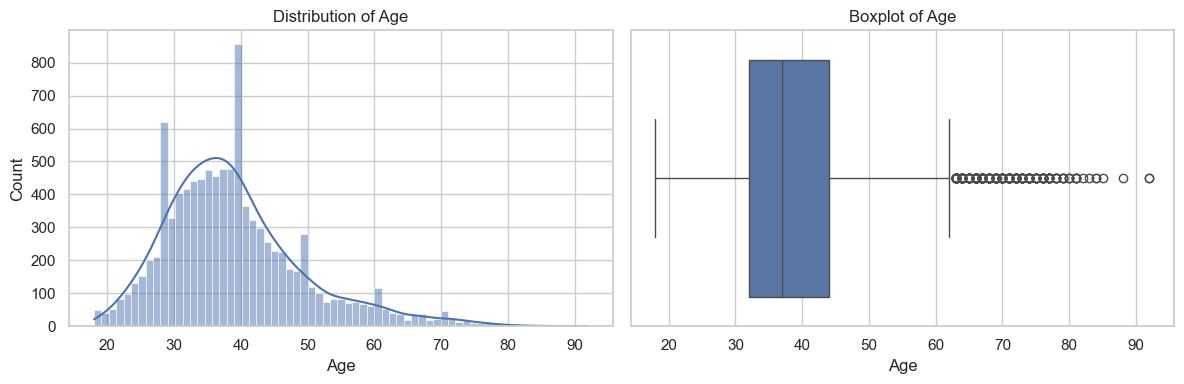

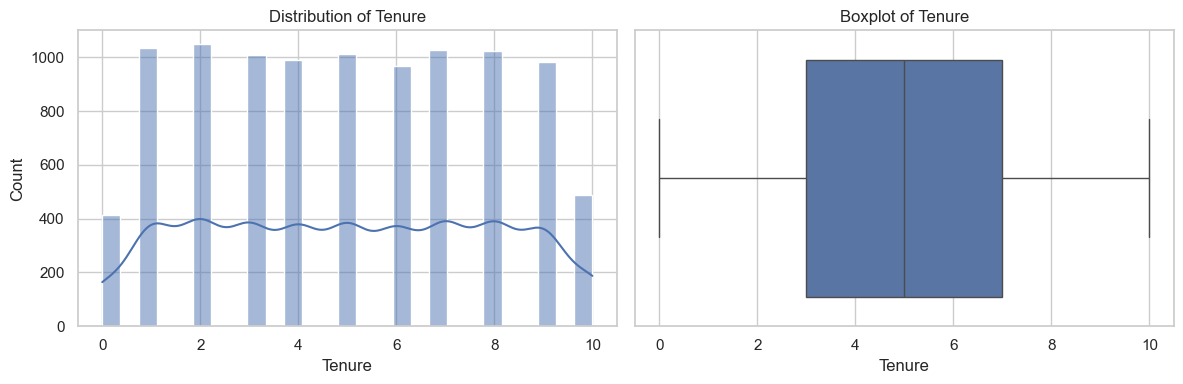

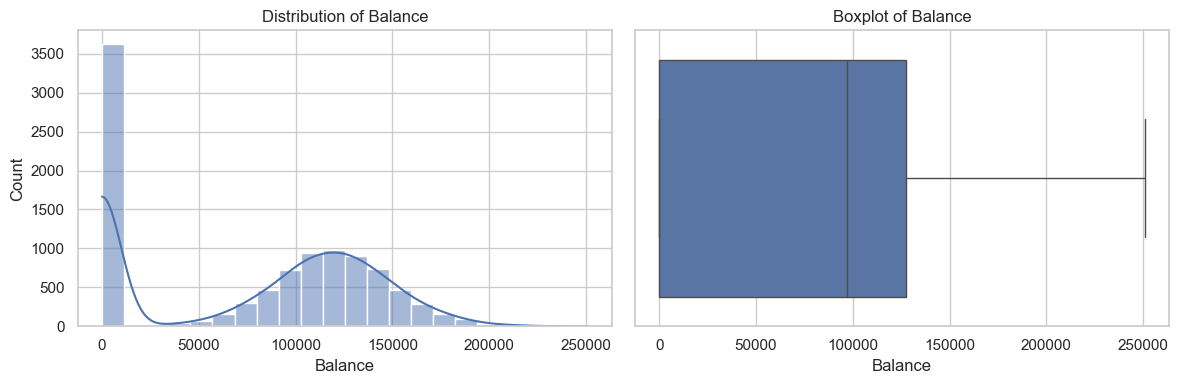

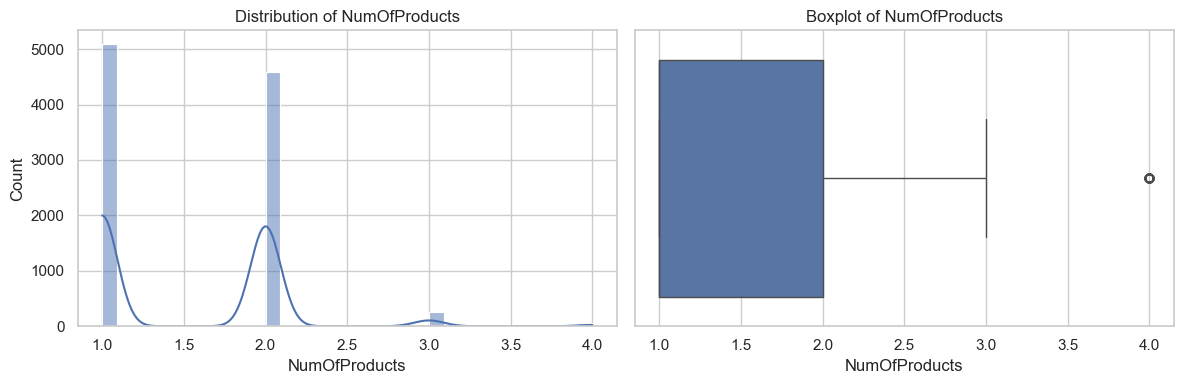

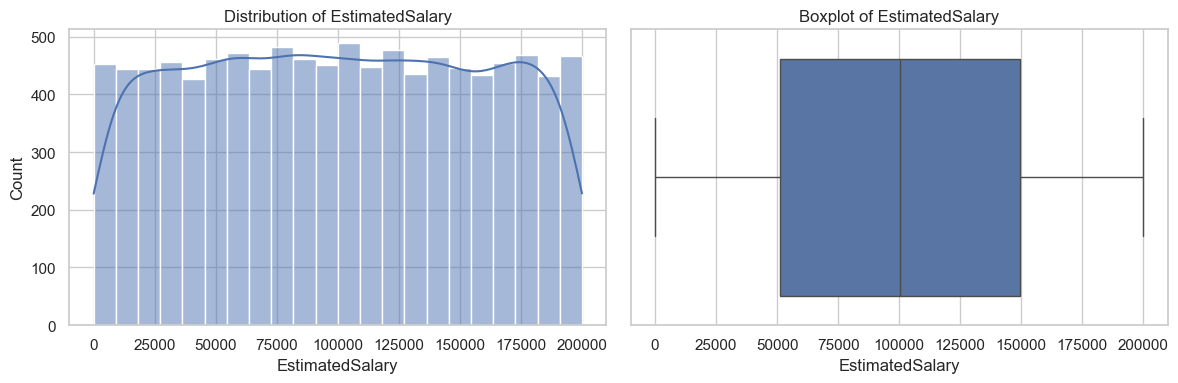

In [10]:
for col in [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]:
    uni.plot_numeric_distribution(col)

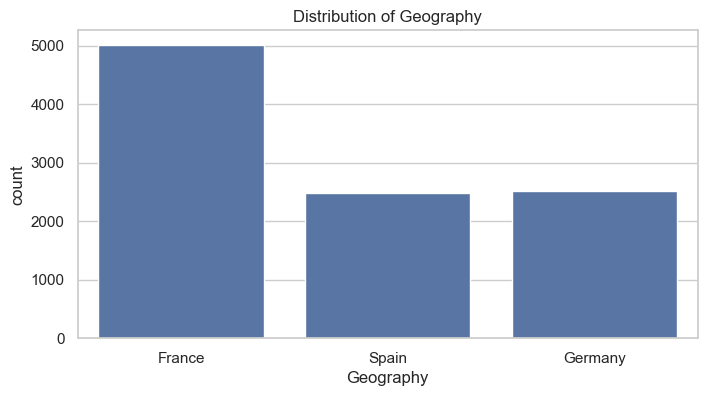

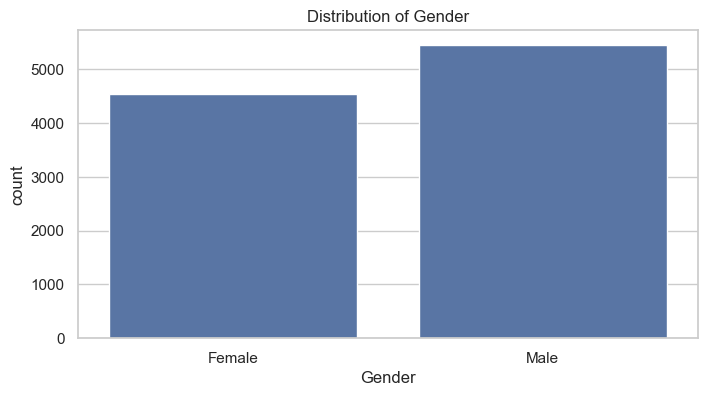

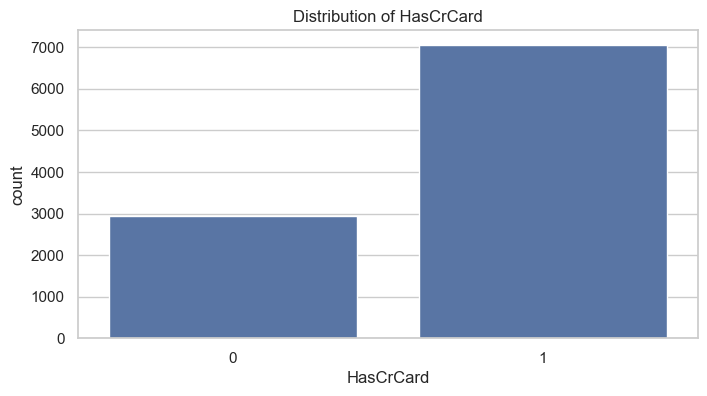

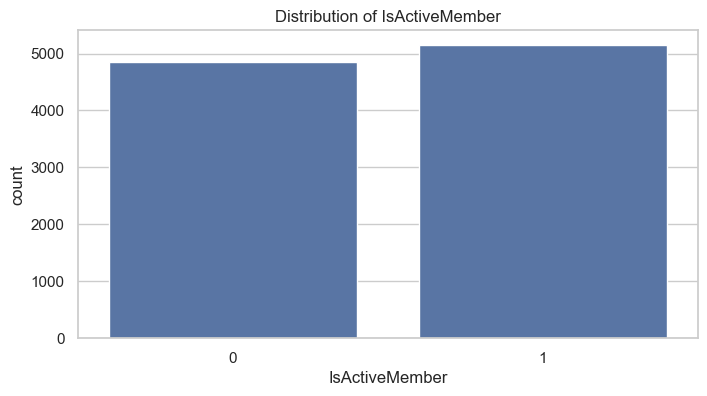

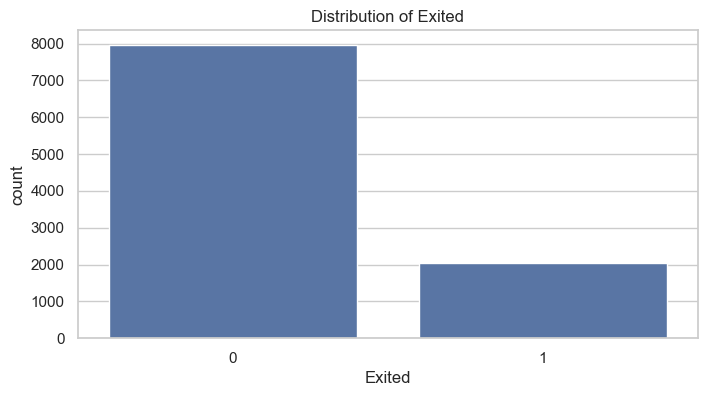

In [ ]:
uni.plot_categorical_distribution("Geography")

uni.plot_categorical_distribution("Gender")

uni.plot_categorical_distribution("HasCrCard")

uni.plot_categorical_distribution("IsActiveMember")

uni.plot_categorical_distribution("Exited")

In [ ]:
class BivariateAnalysis:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def churn_rate_by_category(self, column):
        
        result = (self.df .groupby(column)["Exited"] .mean() .sort_values(ascending=False)* 100)
        
        return result
    
    def plot_churn_by_category(self,column):
        
        plt.figure(figsize=(8,4))
        
        sns.barplot(
            data=self.df,
            x=column,
            y="Exited"
        )
        
        plt.title(
            f"Churn Rate by {column}"
        )
        
        plt.ylabel(
            "Average Churn Rate"
        )
        
        plt.show()
    
    def boxplot_numeric_vs_churn(
        self,
        column
    ):
        
        plt.figure(figsize=(8,4))
        
        sns.boxplot(
            data=self.df,
            x="Exited",
            y=column
        )
        
        plt.title(
            f"{column} vs Churn"
        )
        
        plt.show()

In [13]:
bi = BivariateAnalysis(df_eda)

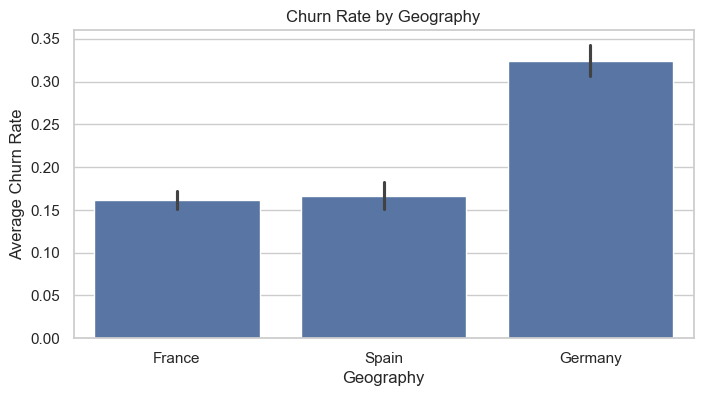

In [14]:
bi.churn_rate_by_category(
    "Geography"
)
bi.plot_churn_by_category(
    "Geography"
)

In [15]:
class CorrelationAnalysis:
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def correlation_matrix(self):
        
        numeric_df = self.df.select_dtypes(
            include=np.number
        )
        
        corr = numeric_df.corr()
        
        plt.figure(
            figsize=(12,8)
        )
        
        sns.heatmap(
            corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )
        
        plt.title(
            "Correlation Matrix"
        )
        
        plt.show()
        
        return corr

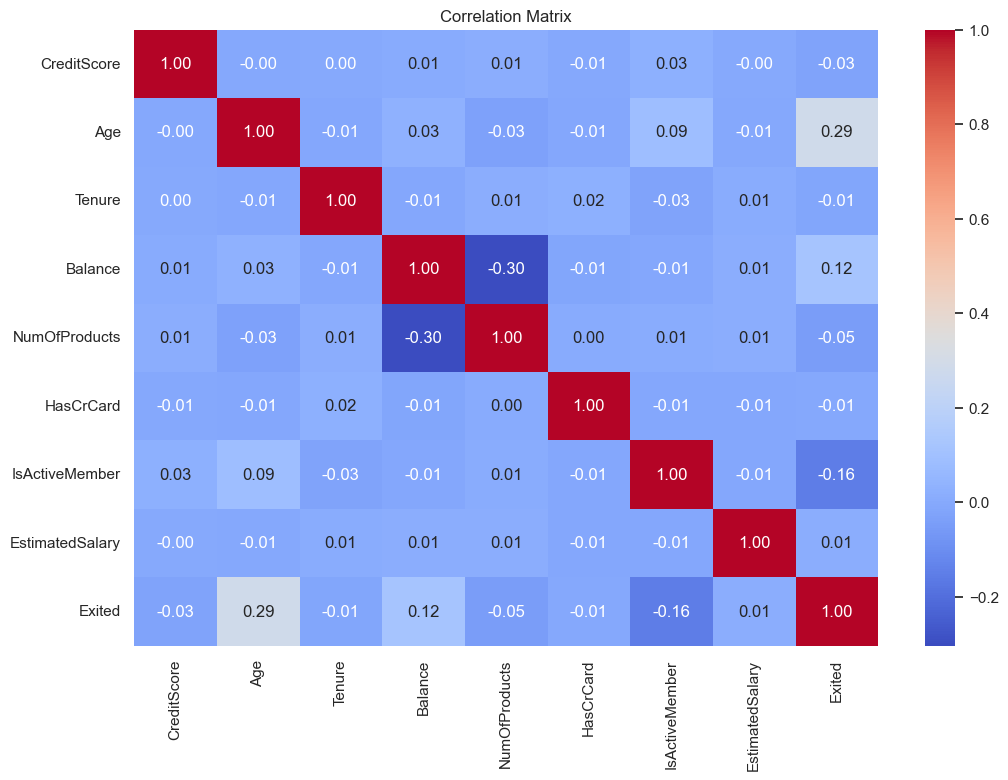

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [16]:
corr = CorrelationAnalysis(df_eda)

corr.correlation_matrix()

In [17]:
df_eda["AgeGroup"] = pd.cut(
    df_eda["Age"],
    bins=[18,30,40,50,100],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "50+"
    ]
)

In [18]:
(
    df_eda
    .groupby("AgeGroup")
    ["Exited"]
    .mean()
    .sort_values(
        ascending=False
    ) * 100
)

AgeGroup
50+      44.647105
41-50    33.965517
31-40    12.087171
18-30     7.502569
Name: Exited, dtype: float64

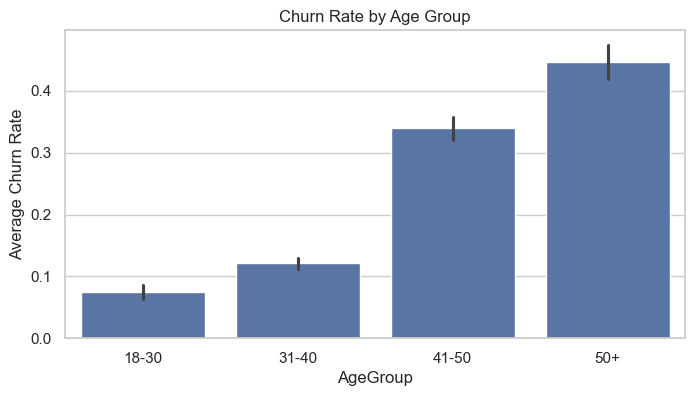

In [19]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=df_eda,
    x="AgeGroup",
    y="Exited"
)

plt.title(
    "Churn Rate by Age Group"
)

plt.ylabel(
    "Average Churn Rate"
)

plt.show()